In [50]:
pip install git+https://github.com/py-why/causal-learn.git

  Cloning https://github.com/py-why/causal-learn.git to c:\users\hp\appdata\local\temp\pip-req-build-qjrilaec
  Resolved https://github.com/py-why/causal-learn.git to commit 9689c1bdc468847729eacf0921b76f598161ae16
  Preparing metadata (setup.py): started
  Preparing metadata (setup.py): finished with status 'done'
  Created wheel for causal-learn: filename=causal_learn-0.1.4.0-py3-none-any.whl size=244011 sha256=16095c40ccda803f0fdc93d123124447c595154cba3aa84bf64a5b90945fd509
  Stored in directory: C:\Users\HP\AppData\Local\Temp\pip-ephem-wheel-cache-9kxzi416\wheels\05\16\0d\aec518a43572c2207dd6a5fa7b10ebdc7c4d7627ff97b3b8d7
Successfully built causal-learn
Note: you may need to restart the kernel to use updated packages.


  Running command git clone --filter=blob:none --quiet https://github.com/py-why/causal-learn.git 'C:\Users\HP\AppData\Local\Temp\pip-req-build-qjrilaec'


In [29]:
import numpy as np
import scipy
import os
import time
import pandas as pd
sig_length = 20
from causalai.models.tabular.pc import PCSingle
from causalai.models.tabular.grow_shrink import GrowShrink

from causalai.models.common.CI_tests.partial_correlation import PartialCorrelation
from causalai.models.common.CI_tests.discrete_ci_tests import DiscreteCI_tests
from causalai.models.common.CI_tests.kci import KCI

from causalai.data.tabular import TabularData
from causalai.data.transforms.time_series import StandardizeTransform
from causalai.models.common.prior_knowledge import PriorKnowledge


In [11]:
# given_params = ['WOW', 'LATP', 'LONP', 'BAL1', 'ROLL', 'PTCH', 'IVV', 'GS', 'CAS', 'VRTG', 'LATG', 'FLAP', 'PLA_2', 'PLA_3', 'PLA_4', 'TRK', 'TH', 'WS', 'WD', 'TAT', 'SAT', 'LOC', 'GLS']

In [12]:
# required_data = np.load("required_data.npy")

# with open("timestamps_save_file.txt", "r") as f:
#         timestamps = f.readlines()
# timestamps = [r.strip() for r in timestamps]

In [13]:
# indices = np.random.choice(len(required_data), size=len(required_data)//1, replace=False)
# print(len(indices))
# required_data = required_data[indices, :]

In [14]:
# required_data.shape[1]

In [15]:
# type(required_data)

In [16]:
# var_names = [x+"-"+str(y) for x in given_params for y in range(sig_length, -1, -1)] + ["touchdown_distance"]

# data_obj = TabularData(required_data, var_names=var_names)

In [17]:
# len(var_names)

In [18]:
# # Is touchdown distance in the var_names ?

# "touchdown_distance" in var_names

In [19]:
# forbidden_links = {}
# for j in var_names:
#     if j == "touchdown_distance" or j == "runway_lat" or j == "runway_lon":
#         continue
#     name, index = j.split("-")
#     index = int(index)
#     for i in range(index):
#         forbidden_links[j] = [x+"-"+str(y) for x in given_params for y in range(index-1, -1, -1)]
        
# forbidden_links = {}
# prior_knowledge = PriorKnowledge(forbidden_links=forbidden_links)a

In [20]:
# pvalue_thres = 0.05
# # CI_test = DiscreteCI_tests()
# # CI_test = PartialCorrelation()
# CI_test = KCI(chunk_size=100) # use if the causal relationship is expected to be non-linear
# pc = PCSingle(
#         data=data_obj,
#         prior_knowledge=prior_knowledge,
#         CI_test=CI_test,
#         use_multiprocessing = False,
#         )

In [21]:
# data_obj

In [22]:
# tic = time.time()
# result = pc.run(target_var="touchdown_distance", pvalue_thres=pvalue_thres, max_condition_set_size=2)
# toc = time.time()

# print(f'Time taken: {toc-tic:.2f}s\n')

# print(f' The output result has keys: {result.keys()}')
# print("parents: ", result["parents"])
# print("value_dict:", result['value_dict'])

---

### LINGAM



In [30]:
from causalai.models.tabular.lingam import LINGAM

lingam = LINGAM(
        data=data_obj,
        prior_knowledge=prior_knowledge
        )

In [31]:
# tic = time.time()
# result = lingam.run(pvalue_thres=0.01)
# toc = time.time()
# print(f'Time taken: {toc-tic:.2f}s\n')
# #

# print(f' The output result has keys: {result.keys()}')
# print(f' The output result["a"] has keys: {result["touchdown_distance"].keys()}')

---

In [33]:
import numpy as np
from causalai.data.tabular import TabularData

# Load your data
required_data = np.load("requiredDataFullUpdated.npy")

# Define variable names
givenParams = ['WOW', 'LATP', 'LONP', 'BAL1', 'ROLL', 'PTCH', 'IVV', 'GS', 'CAS', 'VRTG', 'LATG', 'FLAP', 'PLA_2', 'PLA_3', 'PLA_4', 'TRK', 'TH', 'WS', 'WD', 'TAT', 'SAT', 'LOC', 'GLS']
sig_length = 20  # Adjust this based on your signal length
var_names = [f"{param}_mean" for param in givenParams] + [f"{param}_std" for param in givenParams] + ["TouchdownDistance"]

# Create TabularData object
data_obj = TabularData(required_data, var_names=var_names)


In [46]:
# Create a dataframe from this numpy array
df = pd.DataFrame(data = required_data, columns= var_names)

In [47]:
from lingam import DirectLiNGAM

model = DirectLiNGAM()
model.fit(df)

# Get the adjacency matrix (causal strengths)
adj_matrix = model.adjacency_matrix_

# Check which features cause 'TouchdownDistance'
target_index = df.columns.get_loc("TouchdownDistance")
causal_scores = adj_matrix[:, target_index]

# Sort by influence
influential_features = [(df.columns[i], causal_scores[i]) for i in range(len(causal_scores)) if i != target_index]
influential_features.sort(key=lambda x: abs(x[1]), reverse=True)

print("Top influencing variables (LiNGAM):")
for name, score in influential_features[:10]:
    print(f"{name}: {score}")

Top influencing variables (LiNGAM):
TH_mean: 0.019311782489424695
BAL1_mean: -0.010121045724735106
BAL1_std: -0.0009295218766373157
GS_mean: 0.0009240439342021804
LONP_mean: -0.0005885705809752239
IVV_std: -0.0005667617364889096
LATP_mean: -0.00048182845941355045
TAT_mean: -0.0001292872126120321
GLS_mean: 2.166416216324397e-05
SAT_mean: -3.3751522478688004e-06


In [56]:
from causallearn.search.ConstraintBased.PC import pc
from causallearn.utils.GraphUtils import GraphUtils
from causallearn.utils.cit import fisherz

data_np = df.to_numpy()
pc_graph = pc(data=data_np, 
              independence_test_method=fisherz, 
              alpha=0.05)

import networkx as nx

G = nx.DiGraph()

# Extract edges from the causal graph
for edge in pc_graph.G.get_graph_edges():
    i = edge.get_node1()
    j = edge.get_node2()
    G.add_edge(i.get_name(), j.get_name())  # These return string names like "0", "1", etc.

# Map string node names to actual variable names
mapping = {str(i): name for i, name in enumerate(df.columns)}
G = nx.relabel_nodes(G, mapping)
# From the graph, look for edges pointing to "TouchdownDistance"

Depth=10, working on node 46: 100%|██████████| 47/47 [00:00<00:00, 1103.00it/s]


In [58]:
target = "TouchdownDistance"
influencers = [u for u, v in G.edges() if v == target]
print(f"Variables affecting {target}: {influencers}")

Variables affecting TouchdownDistance: []


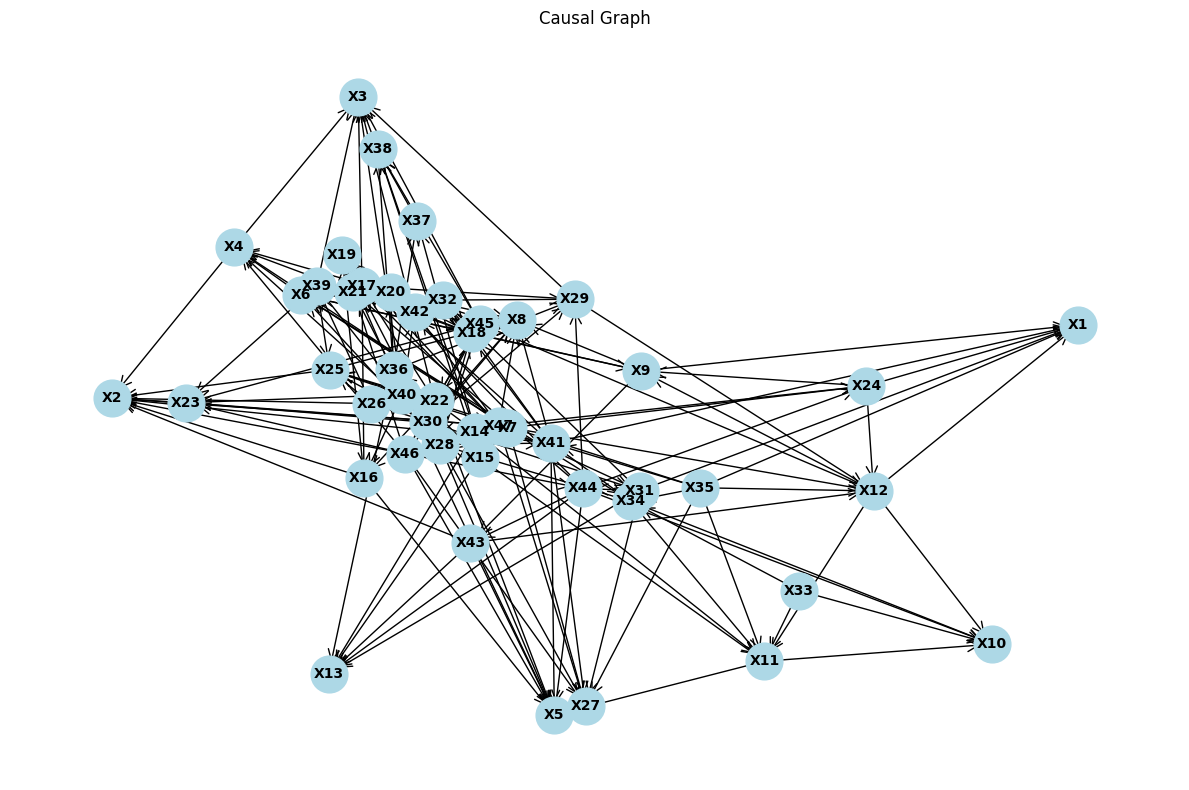

In [57]:
import matplotlib.pyplot as plt
import networkx as nx

plt.figure(figsize=(12, 8))

# Draw the graph
pos = nx.spring_layout(G, seed=42)  # layout for better separation
nx.draw_networkx_nodes(G, pos, node_size=700, node_color="lightblue")
nx.draw_networkx_edges(G, pos, edgelist=G.edges(), arrowstyle="->", arrowsize=20)
nx.draw_networkx_labels(G, pos, font_size=10, font_weight='bold')

plt.title("Causal Graph")
plt.axis("off")
plt.tight_layout()
plt.show()

In [35]:
from causalai.models.tabular.pc import PCSingle
from causalai.models.common.CI_tests.partial_correlation import PartialCorrelation
from causalai.models.common.prior_knowledge import PriorKnowledge

# Initialize the conditional independence test
CI_test = PartialCorrelation()

# Define prior knowledge if any (optional)
prior_knowledge = None  # Replace with PriorKnowledge object if you have prior knowledge

# Initialize the PCSingle object
pc_single = PCSingle(
    data=data_obj,
    prior_knowledge=prior_knowledge,
    CI_test=CI_test,
    use_multiprocessing=False
)


In [36]:
# Define parameters
target_var = 'TouchdownDistance'  # Variable of interest
pvalue_thres = 0.1  # Significance level for independence tests
max_condition_set_size = None  # Maximum size of conditioning set

# Run the PC algorithm
result = pc_single.run(
    target_var=target_var,
    pvalue_thres=pvalue_thres,
    max_condition_set_size=max_condition_set_size
)


In [37]:
import networkx as nx
import matplotlib.pyplot as plt

parents = result['parents']

if not parents:
    print("No parents found for the target variable.")
else:
    G = nx.DiGraph()

    # Add nodes and edges
    G.add_node(target_var)
    for parent, _ in parents:
        G.add_node(parent)
        G.add_edge(parent, target_var)

    # Draw
    plt.figure(figsize=(10, 6))
    pos = nx.spring_layout(G, seed=42)  # layout for reproducibility
    nx.draw(G, pos, with_labels=True,
            node_size=3000, node_color='skyblue',
            font_size=10, font_weight='bold',
            arrowsize=20, edge_color='gray')
    plt.title(f'Causal Graph for {target_var}')
    plt.show()

No parents found for the target variable.


---

# GS Algorithm
Let's break down the Grow-Shrink (GS) algorithm and its components in simple terms, step by step.

**1. Understanding the Goal:**

Imagine you have a dataset with multiple variables (columns), and you're interested in understanding which variables directly influence a specific target variable. The GS algorithm helps identify the "Markov blanket" of this target variable, which is the smallest set of variables that provides all the information needed to predict the target.

**2. What is a Markov Blanket?**

The Markov blanket of a target variable includes:

- **Parents:** Variables that directly cause the target.
- **Children:** Variables that are directly caused by the target.
- **Spouses:** Other parents of the target's children.

Knowing the values of the variables in the Markov blanket makes the target variable conditionally independent of all other variables in the dataset.

**3. The Grow-Shrink Algorithm:**

The GS algorithm identifies the Markov blanket through two main phases:

- **Grow Phase:** Start with an empty set and add variables that show a significant association with the target variable.
- **Shrink Phase:** Remove variables from the set that, when considered with the remaining variables, do not provide additional information about the target.

**4. Conditional Independence Tests:**

To decide whether to add or remove a variable, the algorithm uses Conditional Independence (CI) tests. These tests check if two variables are independent when considering the influence of other variables.

- **For Continuous Data:** The **Partial Correlation** test measures the relationship between two continuous variables while controlling for others.
- **For Categorical Data:** The **Chi-Square Test of Independence** assesses whether two categorical variables are independent.

**5. Test Statistic and p-Value:**

- **Test Statistic:** This is a number calculated from the data that measures the strength of the relationship between variables.
- **p-Value:** This indicates the probability of observing the test statistic by chance if there is no actual relationship. A low p-value (commonly less than 0.05) suggests a significant relationship.

**6. Applying the GS Algorithm:**

- **Grow Phase:** Add variables to the candidate Markov blanket if their association with the target has a p-value below the chosen threshold (e.g., 0.05).
- **Shrink Phase:** Remove variables from the candidate set if, given the remaining variables, their association with the target has a p-value above the threshold.

**7. Assumptions to Keep in Mind:**

- **Sufficient Data:** The algorithm requires enough data to accurately perform CI tests.
- **No Hidden Influences:** It assumes there are no unmeasured variables affecting the relationships.
- **Faithfulness:** The observed data accurately reflects the true underlying relationships.

By following these steps, the GS algorithm helps identify the key variables that directly influence your target variable, providing insights into the causal structure of your data. 

In [38]:
from causalai.models.tabular.grow_shrink import GrowShrink
from causalai.models.common.CI_tests.partial_correlation import PartialCorrelation
from causalai.models.common.prior_knowledge import PriorKnowledge

# Initialize the conditional independence test
CI_test = PartialCorrelation()

# Define prior knowledge if any (optional)
prior_knowledge = None  # Replace with PriorKnowledge object if you have prior knowledge

# Initialize the GrowShrink object
gs = GrowShrink(
    data=data_obj,
    prior_knowledge=prior_knowledge,
    CI_test=CI_test,
    use_multiprocessing=False
)


In [39]:
# Define parameters
target_var = 'TouchdownDistance'  # Variable of interest
pvalue_thres = 0.05  # Significance level for independence tests

# Run the Grow-Shrink algorithm
result = gs.run(
    target_var=target_var,
    pvalue_thres=pvalue_thres
)

# Extract the Markov blanket and associated weights
markov_blanket = result['markov_blanket']
value_dict = result['value_dict']
pvalue_dict = result['pvalue_dict']

# Display the results
print(f"Markov Blanket of {target_var}: {markov_blanket}")
print("\nAssociations and Weights:")
for var in markov_blanket:
    print(f"{var} -> {target_var}: Test Statistic = {value_dict[var]:.4f}, p-value = {pvalue_dict[var]:.4f}")


Markov Blanket of TouchdownDistance: ['BAL1_std', 'WD_mean', 'PLA_2_std', 'WS_std', 'GLS_mean', 'BAL1_mean', 'TH_mean', 'LONP_mean', 'ROLL_std', 'GS_std', 'PTCH_std', 'CAS_std', 'GS_mean', 'TH_std', 'CAS_mean', 'SAT_mean', 'LATP_std', 'SAT_std', 'GLS_std', 'ROLL_mean', 'IVV_mean', 'WOW_mean', 'VRTG_std', 'FLAP_std', 'TRK_std', 'WOW_std', 'LATP_mean', 'LONP_std', 'WD_std', 'TAT_std', 'IVV_std', 'WS_mean', 'TAT_mean', 'TRK_mean']

Associations and Weights:
BAL1_std -> TouchdownDistance: Test Statistic = -0.1490, p-value = 0.0000
WD_mean -> TouchdownDistance: Test Statistic = 0.0432, p-value = 0.0000
PLA_2_std -> TouchdownDistance: Test Statistic = 0.0162, p-value = 0.0006
WS_std -> TouchdownDistance: Test Statistic = 0.0700, p-value = 0.0000
GLS_mean -> TouchdownDistance: Test Statistic = 0.1030, p-value = 0.0000
BAL1_mean -> TouchdownDistance: Test Statistic = -0.0822, p-value = 0.0000
TH_mean -> TouchdownDistance: Test Statistic = 0.0758, p-value = 0.0000
LONP_mean -> TouchdownDistance

In [40]:
documentationDict = {}
with open("variable_documentation.txt", "r") as f:
    for line in f:
        varName, desc = line.split(':')
        documentationDict[varName.strip()] = desc.strip()

In [41]:
mainVars = set(['_'.join(v.split('_')[:-1]) for v in markov_blanket])
for var in mainVars:
    print(f"{var}: {documentationDict[var]}")

PLA_2: POWER LEVER ANGLE 2
WD: WIND DIRECTION TRUE
FLAP: T.E. FLAP POSITION
ROLL: ROLL ANGLE LSP
LONP: LONGITUDE POSITION LSP
TRK: TRACK ANGLE TRUE LSP
IVV: INERTIAL VERTICAL SPEED LSP
VRTG: VERTICAL ACCELERATION
TAT: TOTAL AIR TEMPERATURE
GS: GROUND SPEED LSP
TH: TRUE HEADING LSP
CAS: COMPUTED AIRSPEED LSP
SAT: STATIC AIR TEMPERATURE
BAL1: BARO CORRECT ALTITUDE LSP
WS: WIND SPEED
PTCH: PITCH ANGLE LSP
WOW: WEIGHT ON WHEELS
GLS: GLIDESLOPE DEVIATION
LATP: LATITUDE POSITION LSP


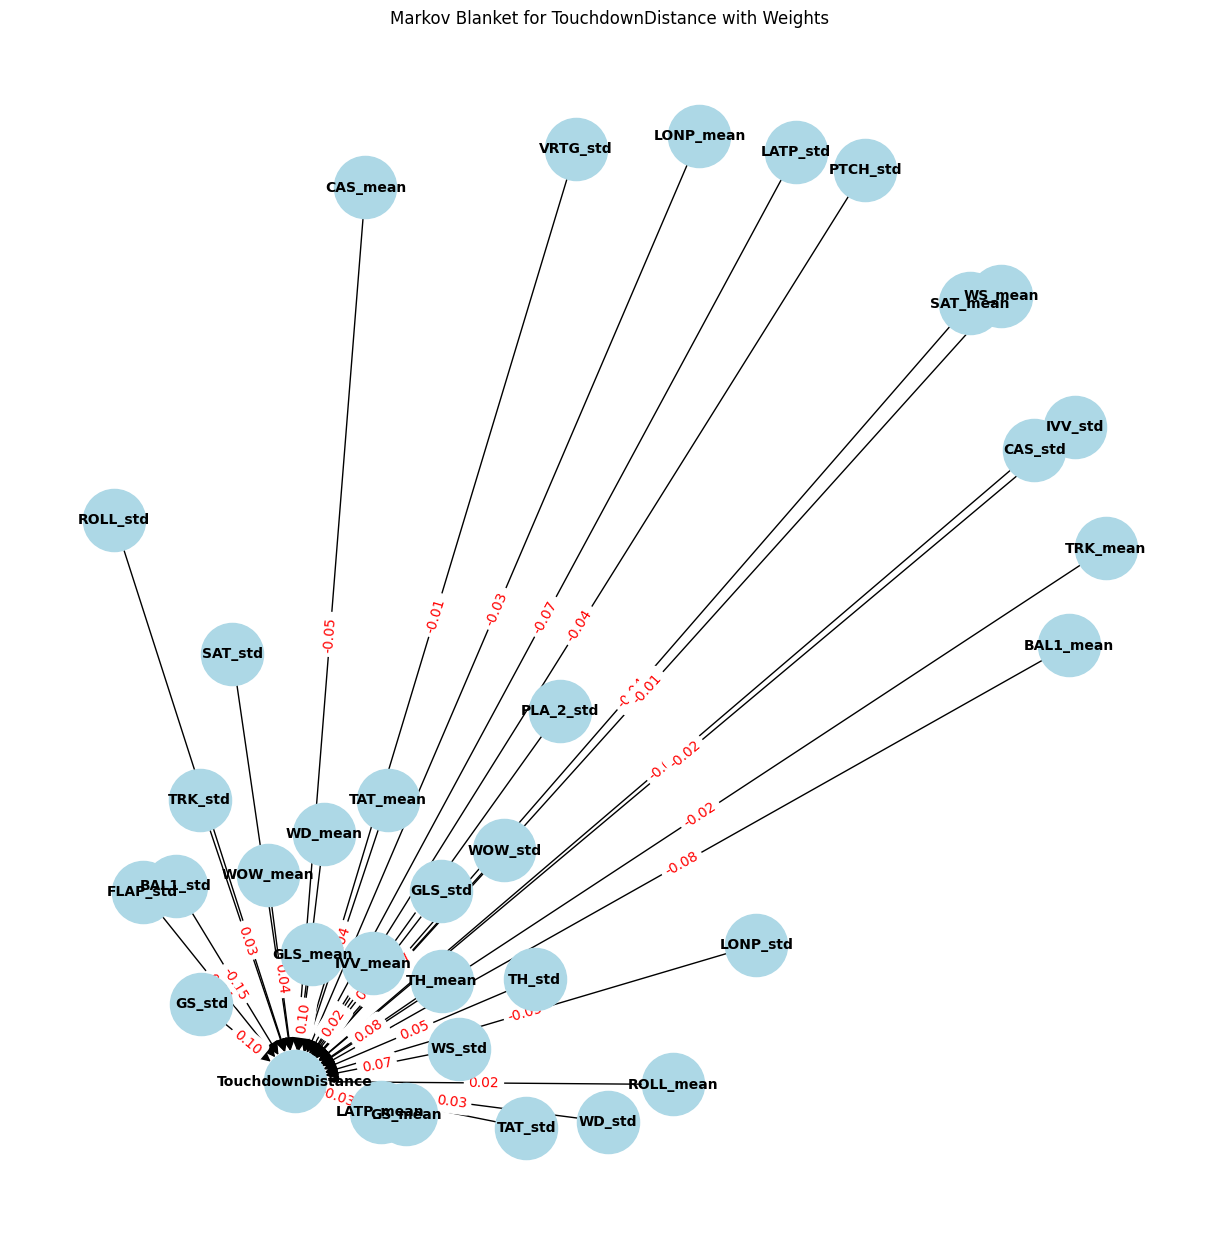

In [42]:
import networkx as nx
import matplotlib.pyplot as plt

# Create a directed graph
G = nx.DiGraph()

# Add edges to the graph with weights
for var in markov_blanket:
    weight = value_dict[var]
    G.add_edge(var, target_var, weight=weight)

# Define edge labels with weights
edge_labels = {(u, v): f"{d['weight']:.2f}" for u, v, d in G.edges(data=True)}

# Draw the graph
plt.figure(figsize=(12, 12))
pos = nx.spring_layout(G)
nx.draw(G, pos, with_labels=True, node_size=2000, node_color='lightblue', font_size=10, font_weight='bold', arrowsize=20)
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_color='red')
plt.title(f'Markov Blanket for {target_var} with Weights')
plt.show()


The results you've obtained from the Grow-Shrink algorithm provide insights into the variables that have a statistically significant association with the touchdown distance, which is a critical factor in understanding long landings. Here's a breakdown of what these findings imply:

**1. Understanding the Associations:**

Each line in your results indicates a variable (e.g., `VRTG-18`) that has a significant relationship with `touchdown_distance`. The test statistic reflects the strength and direction of this association, while the p-value indicates the statistical significance.

- **Test Statistic:** A positive value suggests a direct relationship (as the variable increases, so does the touchdown distance), whereas a negative value indicates an inverse relationship.

- **P-Value:** A p-value less than 0.05 typically denotes a statistically significant association, meaning it's unlikely that the observed relationship is due to random chance.

**2. Interpreting Specific Variables:**

Let's examine a few variables from your results:

- **`VRTG-18` (Vertical Speed at time lag 18):** Test Statistic = -0.0385, p-value = 0.0363. This negative association suggests that higher vertical speeds at this time lag are associated with shorter touchdown distances, potentially indicating a steeper descent leading to an earlier touchdown.

- **`PLA_3-15` (Position of Lever Angle 3 at time lag 15):** Test Statistic = 0.0723, p-value = 0.0001. A positive association here implies that higher lever angles at this time lag are linked to longer touchdown distances, possibly due to delayed deployment of control surfaces affecting landing.

- **`LONP-13` (Longitudinal Position at time lag 13):** Test Statistic = -0.0454, p-value = 0.0135. This negative relationship indicates that certain longitudinal positions at this time lag correlate with shorter touchdown distances, which could be related to the aircraft's approach path.

**3. Drawing Logical Inferences:**

- **Operational Adjustments:** Understanding these associations allows pilots and flight operations to adjust specific parameters during approach to achieve optimal touchdown distances, thereby reducing the risk of long landings.

- **Training and Procedures:** Highlighting the significance of variables like lever angles and vertical speed can inform training programs, emphasizing the importance of managing these parameters during critical phases of flight.

- **Predictive Maintenance:** If certain control positions consistently correlate with longer touchdown distances, it may prompt a review of aircraft systems to ensure they respond appropriately to control inputs.

**4. Caution in Interpretation:**

While these associations are statistically significant, it's essential to consider the following:

- **Causation vs. Correlation:** These results indicate associations but do not establish direct causation. Further analysis is needed to confirm causal relationships.

- **Operational Context:** The practical significance of these associations should be evaluated within the context of standard operating procedures and environmental conditions.

In summary, the identified variables provide valuable insights into factors influencing touchdown distance. By focusing on these parameters, aviation professionals can develop strategies to mitigate long landings, enhancing safety and efficiency. 

Here are the interpretations for each variable based on the test statistics and p-values:

- **`CAS-9` (Calibrated Airspeed at time lag 9):** Test Statistic = 0.0416, p-value = 0.0237. This positive association suggests that a higher calibrated airspeed at this time lag correlates with a longer touchdown distance, possibly indicating higher ground speed on approach.

- **`PTCH-0` (Pitch Angle at time lag 0):** Test Statistic = 0.0462, p-value = 0.0119. A positive association here implies that an increased pitch angle at this time is linked to a longer touchdown distance, possibly due to a more nose-up attitude during the landing flare.

- **`LONP-15` (Longitudinal Position at time lag 15):** Test Statistic = -0.0407, p-value = 0.0268. This negative association suggests that a certain longitudinal position of the aircraft at this time lag is linked to a shorter touchdown distance, possibly related to the approach path or alignment.

- **`PLA_2-15` (Position of Lever Angle 2 at time lag 15):** Test Statistic = -0.0581, p-value = 0.0016. This negative association suggests that a specific lever angle at this time lag is related to a shorter touchdown distance, which might reflect control inputs that prompt a quicker descent.

- **`PLA_4-16` (Position of Lever Angle 4 at time lag 16):** Test Statistic = -0.0486, p-value = 0.0082. Here, a negative association indicates that a specific setting for Lever Angle 4 corresponds to a shorter touchdown distance, potentially due to timely adjustments in flight controls.

- **`GLS-1` (Glide Slope at time lag 1):** Test Statistic = 0.0367, p-value = 0.0457. A positive association suggests that being on or above the glide slope at this time lag is associated with a longer touchdown distance, potentially due to a shallower descent path.

- **`LONP-19` (Longitudinal Position at time lag 19):** Test Statistic = 0.0456, p-value = 0.0130. This positive association implies that the aircraft’s position at this point on approach is linked to a longer touchdown distance, possibly due to trajectory adjustments late in the approach.

- **`LONP-20` (Longitudinal Position at time lag 20):** Test Statistic = -0.0489, p-value = 0.0078. A negative association here suggests that at this position, the aircraft may achieve a shorter touchdown distance, likely linked to specific approach positions favorable to an early landing.

- **`VRTG-17` (Vertical Speed at time lag 17):** Test Statistic = 0.0393, p-value = 0.0323. This positive association suggests that a higher descent rate at this time lag is associated with a longer touchdown distance, potentially indicating that a quick descent is leading to a later touchdown.

- **`PLA_3-13` (Position of Lever Angle 3 at time lag 13):** Test Statistic = -0.0755, p-value = 0.0000. The strong negative association implies that specific settings for Lever Angle 3 at this time lag may contribute to a shorter touchdown distance, likely through control adjustments that encourage an earlier touchdown.

- **`PLA_2-13` (Position of Lever Angle 2 at time lag 13):** Test Statistic = 0.0697, p-value = 0.0001. This positive association indicates that a specific Lever Angle 2 setting at this time is linked to a longer touchdown distance, suggesting a delayed approach or flare timing. 

Each variable here offers insights into how aircraft positions and control inputs during approach are associated with touchdown distance. Variables with negative test statistics (such as `VRTG-18`, `PLA_4-16`, and `PLA_3-13`) indicate actions or states that may shorten touchdown distance, while positive test statistics (like `PLA_3-15` and `CAS-9`) suggest associations with longer touchdown distances. These insights could be valuable for adjusting flight parameters to optimize landing distance and minimize the risk of long landings.

---

The varying performance of the causal discovery algorithms you've applied—PC, LiNGAM, GIN, and Grow-Shrink (GS)—can be attributed to their underlying methodologies and computational complexities:

1. **PC Algorithm:**
   - **Methodology:** The PC (Peter-Clark) algorithm is a constraint-based method that identifies causal structures by performing conditional independence tests among variables.
   - **Performance:** In high-dimensional datasets, the PC algorithm may encounter challenges due to the exponential increase in the number of conditional independence tests required. This can lead to situations where the algorithm fails to identify significant features, especially if the dataset is large or the relationships are complex.

2. **LiNGAM and GIN Algorithms:**
   - **Methodology:** Both LiNGAM (Linear Non-Gaussian Acyclic Model) and GIN (Generalized Independence Noise) are model-based approaches that assume linear relationships with non-Gaussian noise. They aim to uncover causal directions by exploiting statistical properties of the data.
   - **Performance:** These algorithms often involve complex computations, such as matrix operations and optimization procedures, which can be computationally intensive. In large datasets, this can result in prolonged runtimes or even failure to produce results within a reasonable timeframe.

3. **Grow-Shrink (GS) Algorithm:**
   - **Methodology:** The GS algorithm is a constraint-based method that identifies the Markov blanket of a target variable through a two-phase process:
     - **Grow Phase:** Incrementally adds variables that are conditionally dependent on the target.
     - **Shrink Phase:** Removes variables that become conditionally independent when conditioned on the current set.
   - **Performance:** The GS algorithm is generally more efficient in high-dimensional settings because it focuses on identifying a subset of relevant variables (the Markov blanket) rather than evaluating all possible relationships. This targeted approach reduces computational overhead, leading to faster execution times and the identification of significant features, even in larger datasets.

**Summary:**
The differences in performance among these algorithms stem from their distinct approaches to causal discovery and their computational demands. The GS algorithm's efficiency and focus on relevant variables make it more suitable for large datasets, whereas the PC, LiNGAM, and GIN algorithms may struggle with scalability and complexity, leading to longer runtimes or lack of results. 